# 0. Estimação de altura baseada em imagens da água

# 1. Importação das bibliotecas padrão

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#importar tensorflow e auxiliares
import tensorflow as tf
from tensorflow import keras

from keras import models
from keras import layers
from keras import optimizers
from keras.callbacks import ModelCheckpoint
from keras.layers import Conv2D
from keras.layers import Dense, Activation, Flatten, MaxPooling2D
from sklearn.metrics import classification_report, confusion_matrix

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
from PIL import Image


import os

print(tf.__version__)

2.15.0


# 2. Extração do banco de imagens sintéticas.
Ignorar em caso de ter concluído a extração previamente.

A operação é feita com o comando `unzip` por rodar diretamente no sistema do backend, sem passar pelo interpretador do script. Dessa maneira, a operação funciona mais rapidamente.

In [ ]:
! unzip -q /content/drive/MyDrive/agua/banco_agua.zip -d /content/

In [ ]:
directory = "/content/banco_agua/"
files_in_directory = os.listdir(directory)
len(files_in_directory)

188560

# 3. Carregamento do dataframe e banco de imagens

As imagens são catalogadas por um .csv contendo as colunas <br>
['nome'], <br>
['distancia'], <br>
['motion'], <br>
['gauss'] <br>

Que representam, respectivamente, nome do arquivo referenciado, distância da superfície da água (altitude simulada), direção do motion blur (0 para fixo, 1 para vertical, 2 para horizontal e 3 para diagonal), e intensidade de distorção de gauss.

## 3.1. Dataframe

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/agua/data.csv')
data_dir = '/content/banco_agua'

#normalizar o label de altura do dataframe, altura max 800cm -> 1
df['distancia'] = df['distancia'].map(lambda distancia: distancia/800)

In [ ]:
#seleciona 60% do DF para treino .6*len(df), e 20%+20% para teste e validacao .8*len(df)
#frac=100%, random_state=42 (garantindo a seed como constante teremos sempre os mesmos sets para cada divisao)
#df_train, df_validate, df_test = np.split(df.sample(frac=1, random_state=42), [int(.42*len(df)), int(.8*len(df))])
df_train, df_test = np.split(df.sample(frac=1, random_state=42), [int(.80*len(df))])

df_test = df_test.sort_values('distancia')

data_trainX = df_train[['nome']].values
data_trainY = df_train[['distancia']].values
data_testX = df_test[['nome']].values
data_testY = df_test[['distancia']].values

print('train {}, test {}'.format(len(df_train), len(df_test)))
df_test

train 150847, test 37712


,nome,distancia,motion,gauss
28821,50_vert_8970.jpg,0.0625,1,0
31247,50_diag_6182.jpg,0.0625,2,0
26999,50_vert_1394.jpg,0.0625,1,6
33290,50_std_6518.jpg,0.0625,0,5
27961,50_vert_2162.jpg,0.0625,1,0
...,...,...,...,...
163617,800_vert_6212.jpg,1.0000,1,0
168266,800_std_8898.jpg,1.0000,0,5
162008,800_vert_5689.jpg,1.0000,1,6
167793,800_std_5632.jpg,1.0000,0,4


## 3.2. Imagens

In [ ]:
#normalizando as imagens do conjunto de treino e de teste
#treino
#from tf.keras.preprocessing.image.ImageDataGenerator import ImageDataGenerator

#1.0/255 normaliza o valor dos pixels em 8 bits
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255,
                                     validation_split=0.33)

#teste
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

In [ ]:
#conferir depois featurewise_std_normalization

train_images = train_generator.flow_from_dataframe(
    dataframe = df_train,
    directory = data_dir,
    validate_filenames=False,
    x_col = 'nome',
    y_col = 'distancia',
    seed = 42,
    batch_size = 256,
    shuffle = True,
    class_mode="raw",
    target_size = (224, 224),
    color_mode='grayscale',
    subset='training')

val_images = train_generator.flow_from_dataframe(
    dataframe = df_train,
    directory = data_dir,
    validate_filenames=False,
    x_col = 'nome',
    y_col = 'distancia',
    seed = 42,
    batch_size = 256,
    shuffle = True,
    class_mode="raw",
    target_size = (224, 224),
    color_mode='grayscale',
    subset='validation' )

test_images = test_generator.flow_from_dataframe(
    dataframe = df_test,
    directory = data_dir,
    validate_filenames=False,
    x_col = 'nome',
    y_col = 'distancia',
    batch_size = 1, #batch de uma foto por vez pra predicao
    class_mode="raw",
    target_size = (224, 224),
    color_mode='grayscale',
    shuffle = False)

#test_images_dir = test_generator.flow_from_directory(
#    '/home/workstation/Desktop/treino_agua/test/',
#    target_size=(224,224),
#    batch_size=1,
#    class_mode='categorical',
#    shuffle=False)

#test_cabedelo = test_generator.flow_from_directory(
#    '/home/workstation/Desktop/banco_real/cabedelo2_v/cabedelo0',
#    target_size=(224,224),
#    batch_size=1,
#    class_mode='input',
#    shuffle=False)

Found 101068 validated image filenames.
Found 49779 validated image filenames.
Found 37712 validated image filenames.


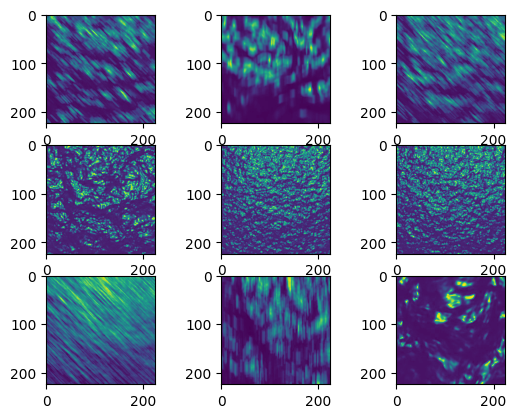

In [ ]:
# create a grid of 3*3 images to visualize some of the images in dataset
for i in range(0, 9):
    plt.subplot(330 + 1+ i)
    img = train_images[0][0][i]
    plt.imshow(img)

# show the plot
plt.show()

In [ ]:
model = models.Sequential()
# Atencao para a entrada, sempre com resolucao de 224 x 224 com 1 byte de cor

batch_size_drop = 16
# Convolucao 1
model.add(Conv2D(32, kernel_size=5, activation='relu', input_shape=(224,224,1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
# Convolucao 2
model.add(Conv2D(64, kernel_size=5, strides = (2,2), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
# Convolucao 3
model.add(Conv2D(128, kernel_size=5, strides = (2,2), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(tf.keras.layers.Dropout(0.2, input_shape = (batch_size_drop, ), seed=42))
# Convolucao 4
model.add(Conv2D(256, kernel_size=5, strides = (1,1), activation='relu'))
#model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(tf.keras.layers.Dropout(0.2, input_shape = (batch_size_drop, ), seed=42))

model.add(Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2, input_shape = (batch_size_drop, ), seed=42))

model.add(layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2, input_shape = (batch_size_drop, ), seed=42))

model.add(Dense(1, activation='linear'))

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu')(inputs)
x = tf.keras.layers.MaxPool2D()(x)
x = tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPool2D()(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
outputs = tf.keras.layers.Dense(1, activation='linear')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 220, 220, 32)      832       
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 110, 110, 32)      0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 53, 53, 64)        51264     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 26, 26, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 11, 11, 128)       204928    
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 5, 5, 128)        

In [ ]:
from tensorflow.keras.optimizers import RMSprop

model.compile(optimizer= 'adam',
              loss='mse',
              metrics=[tf.keras.metrics.RootMeanSquaredError()])

In [ ]:
# checkpoint
dir_checkpoint='/content/drive/MyDrive/agua/checkpoint_teste'
#checkpoint = ModelCheckpoint(filepath, monitor=tf.keras.metrics.MeanSquaredError(), verbose=1, save_best_only=True, mode='max')
#callbacks_list = [checkpoint]

checkpoint = [
    tf.keras.callbacks.EarlyStopping(patience=5),
    tf.keras.callbacks.ModelCheckpoint(filepath=dir_checkpoint+'/model.{epoch:02d}-{val_loss:.4f}.keras'),
    tf.keras.callbacks.TensorBoard(log_dir='./logs'),
]

In [ ]:
# Train the model

history = model.fit(
    train_images,
    validation_data = val_images,
    epochs=100,
    batch_size=32,
    callbacks=checkpoint
)


Epoch 1/100
395/395 [==============================] - 183s 426ms/step - loss: 0.0348 - root_mean_squared_error: 0.1865 - val_loss: 0.0077 - val_root_mean_squared_error: 0.0877
Epoch 2/100
395/395 [==============================] - 160s 406ms/step - loss: 0.0044 - root_mean_squared_error: 0.0664 - val_loss: 0.0033 - val_root_mean_squared_error: 0.0574
Epoch 3/100
395/395 [==============================] - 160s 406ms/step - loss: 0.0041 - root_mean_squared_error: 0.0638 - val_loss: 0.0025 - val_root_mean_squared_error: 0.0499
Epoch 4/100
395/395 [==============================] - 160s 405ms/step - loss: 0.0028 - root_mean_squared_error: 0.0534 - val_loss: 0.0016 - val_root_mean_squared_error: 0.0405
Epoch 5/100
395/395 [==============================] - 158s 400ms/step - loss: 0.0027 - root_mean_squared_error: 0.0517 - val_loss: 0.0016 - val_root_mean_squared_error: 0.0395
Epoch 6/100
395/395 [==============================] - 159s 401ms/step - loss: 0.0023 - root_mean_squared_error: 0.

dict_keys(['loss', 'root_mean_squared_error', 'val_loss', 'val_root_mean_squared_error'])


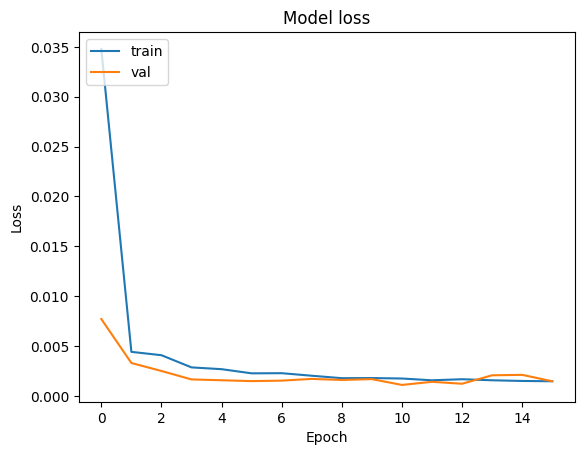

In [ ]:
# Plotting the Loss and Classification Accuracy
model.metrics_names
print(history.history.keys())
#  "Accuracy"
#plt.plot(history.history['acc'])
#plt.plot(history.history['val_acc'])
#plt.title('Model Accuracy')
#plt.ylabel('Accuracy')
#plt.xlabel('Epoch')
#plt.legend(['train', 'test'], loc='upper left')
#plt.show()

# "Loss"
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.savefig('/content/drive/MyDrive/agua/checkpoint_teste/train_loss.jpg', format='jpg', dpi=720)
plt.show()

In [ ]:
hist_backup = pd.DataFrame(history.history)

hist_backup.to_csv('/content/drive/MyDrive/agua/checkpoint_teste/train_loss.csv')
hist_backup.head()

,loss,root_mean_squared_error,val_loss,val_root_mean_squared_error
0,0.034795,0.186535,0.007699,0.087745
1,0.004408,0.066395,0.003290,0.057357
2,0.004072,0.063809,0.002490,0.049897
3,0.002850,0.053384,0.001642,0.040527
4,0.002671,0.051678,0.001560,0.039493


In [ ]:
# loading the weights with ~97% acc
from keras.models import load_model
model = load_model('/home/workstation/Desktop/resultados/adagrad/normalizado/model.100-0.00.h5')

In [ ]:
sumario = model.summary()
sumario

Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_23 (Conv2D)           (None, 220, 220, 32)      2432      
_________________________________________________________________
max_pooling2d_23 (MaxPooling (None, 110, 110, 32)      0         
_________________________________________________________________
conv2d_24 (Conv2D)           (None, 53, 53, 64)        51264     
_________________________________________________________________
max_pooling2d_24 (MaxPooling (None, 26, 26, 64)        0         
_________________________________________________________________
conv2d_25 (Conv2D)           (None, 11, 11, 128)       204928    
_________________________________________________________________
max_pooling2d_25 (MaxPooling (None, 5, 5, 128)         0         
_________________________________________________________________
conv2d_26 (Conv2D)           (None, 1, 1, 256)        

In [ ]:
layers = model.layers
#layers[11].get_weights()[0][0]

offset_bias = layers[11].get_weights()[0][0]*800

print(offset_bias)

[15.8786745]


In [ ]:
test_mse, test_rmse = model.evaluate(test_cabedelo)

#test_set.class_indices[np.argmax(predicao_unitaria[numero_label])]

#print([key for key in test_set.class_indices.keys()][numero_label])

56524/56524 [==============================] - 282s 5ms/step - loss: 0.0857 - root_mean_squared_error: 0.2928


In [ ]:
#retorna o tipo de metricas disponiveis
print(model.metrics_names)
print("Test_loss: {}, Test_acc: {} \n ==============================".format(test_mse, test_rmse), end="\n")

['loss', 'root_mean_squared_error']
Test_loss: 0.08574248850345612, Test_acc: 0.2928200662136078 


In [ ]:
test_images.reset()
pred=model.predict_generator(test_cabedelo,
                             steps=test_cabedelo.n//test_cabedelo.batch_size,
                             verbose=1)

   37/56524 [..............................] - ETA: 2:42

/home/workstation/.local/bin/.virtualenvs/dl4cv/lib/python3.8/site-packages/tensorflow/python/keras/engine/training.py:1905: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  warnings.warn('`Model.predict_generator` is deprecated and '


56524/56524 [==============================] - 154s 3ms/step


In [ ]:
#y_pred = np.argmax(pred_dir, axis=1)

num = 100

print('orig: {}, filename: {}'.format(test_cabedelo.classes[num], test_cabedelo.filenames[num]))
print('pred: {}'.format(pred[num]*800))

cabedelo_dique = []
for k in range(len(test_cabedelo.classes)):
    if test_cabedelo.classes[k] == 0:
        cabedelo_dique.append(50)
    elif test_cabedelo.classes[k] == 1:
        cabedelo_dique.append(70)
    elif test_cabedelo.classes[k] == 2:
        cabedelo_dique.append(100)
    elif test_cabedelo.classes[k] == 3:
        cabedelo_dique.append(150)
    elif test_cabedelo.classes[k] == 4:
        cabedelo_dique.append(230)
    elif test_cabedelo.classes[k] == 5:
        cabedelo_dique.append(280)
    elif test_cabedelo.classes[k] == 6:
        cabedelo_dique.append(330)

cabedelo_pedras = []
for k in range(len(test_cabedelo.classes)):
    if test_cabedelo.classes[k] == 0:
        cabedelo_pedras.append(50)
    elif test_cabedelo.classes[k] == 1:
        cabedelo_pedras.append(70)



orig: 0, filename: 100/32741.jpg
pred: [564.26166]


# ATRIBUIR CADA CLASSE COM UM VALOR INT PARA GERAR O GRÁFICO

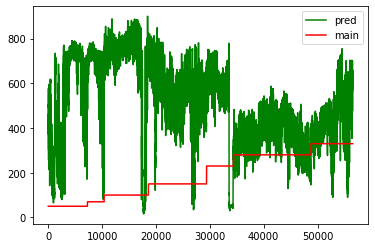

In [ ]:
plt.plot(test_cabedelo.index_array, (pred*800)-offset_bias, 'g')
plt.plot(test_cabedelo.index_array, cabedelo_pedras, 'r')
plt.legend(['pred', 'main'])
plt.savefig('/home/workstation/Desktop/cabedelo_pedras.jpg', format='jpg', dpi=720)
plt.show()

In [ ]:
filenames=test_cabedelo.filenames

pred_list = []
dif = []
for k in range (len(pred)):
    pred_list.append(pred[k][0]*800)
    dif.append((pred[k][0]*800)-cabedelo_dique[k])

results=pd.DataFrame({"Filename":filenames,
                      "Predictions":pred_list,
                      "Real":cabedelo_dique,
                      "Dif": dif})
results.to_csv("/home/workstation/Desktop/results_cabedelo_dique.csv", index=True)

avg_50 = sum(pred_list[:14398])/len(pred_list[:14398])
avg_70 = sum(pred_list[14399:22137])/len(pred_list[14399:22138])
avg_100 = sum(pred_list[22139:29396])/len(pred_list[22139:29396])
avg_150 = sum(pred_list[29397:32503])/len(pred_list[29397:32503])
avg_230 = sum(pred_list[32503:40721])/len(pred_list[32503:40721])
avg_280 = sum(pred_list[40722:51520])/len(pred_list[40722:51520])
avg_330 = sum(pred_list[51521:])/len(pred_list[51521:])

print("Media das predicoes \n50cm: {} \n70cm {} \n100cm {} \n150cm {} \n230cm {} \n280cm {} \n330cm {}".format(avg_50, avg_70, avg_100, avg_150, avg_230, avg_280, avg_330))

Media das predicoes 
50cm: 630.3588638538816 
70cm 655.1479133143722 
100cm 541.4768530659823 
150cm 644.1317671740815 
230cm 387.62456328946035 
280cm 405.8026136524436 
330cm 508.6032393668238


In [ ]:
print("nomes: {}, predicoes: {}".format(len(filenames), len(pred_list)))


nomes: 37712, predicoes: 37712
